In [2]:
pip install ucimlrepo

In [3]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from ucimlrepo import fetch_ucirepo


warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [ ]:
# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)

# data (as pandas dataframes)
X = real_estate_valuation.data.features
y = real_estate_valuation.data.targets

# metadata
print(real_estate_valuation.metadata)

# variable information
print(real_estate_valuation.variables)

In [25]:
real_estate_valuation.data.features

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


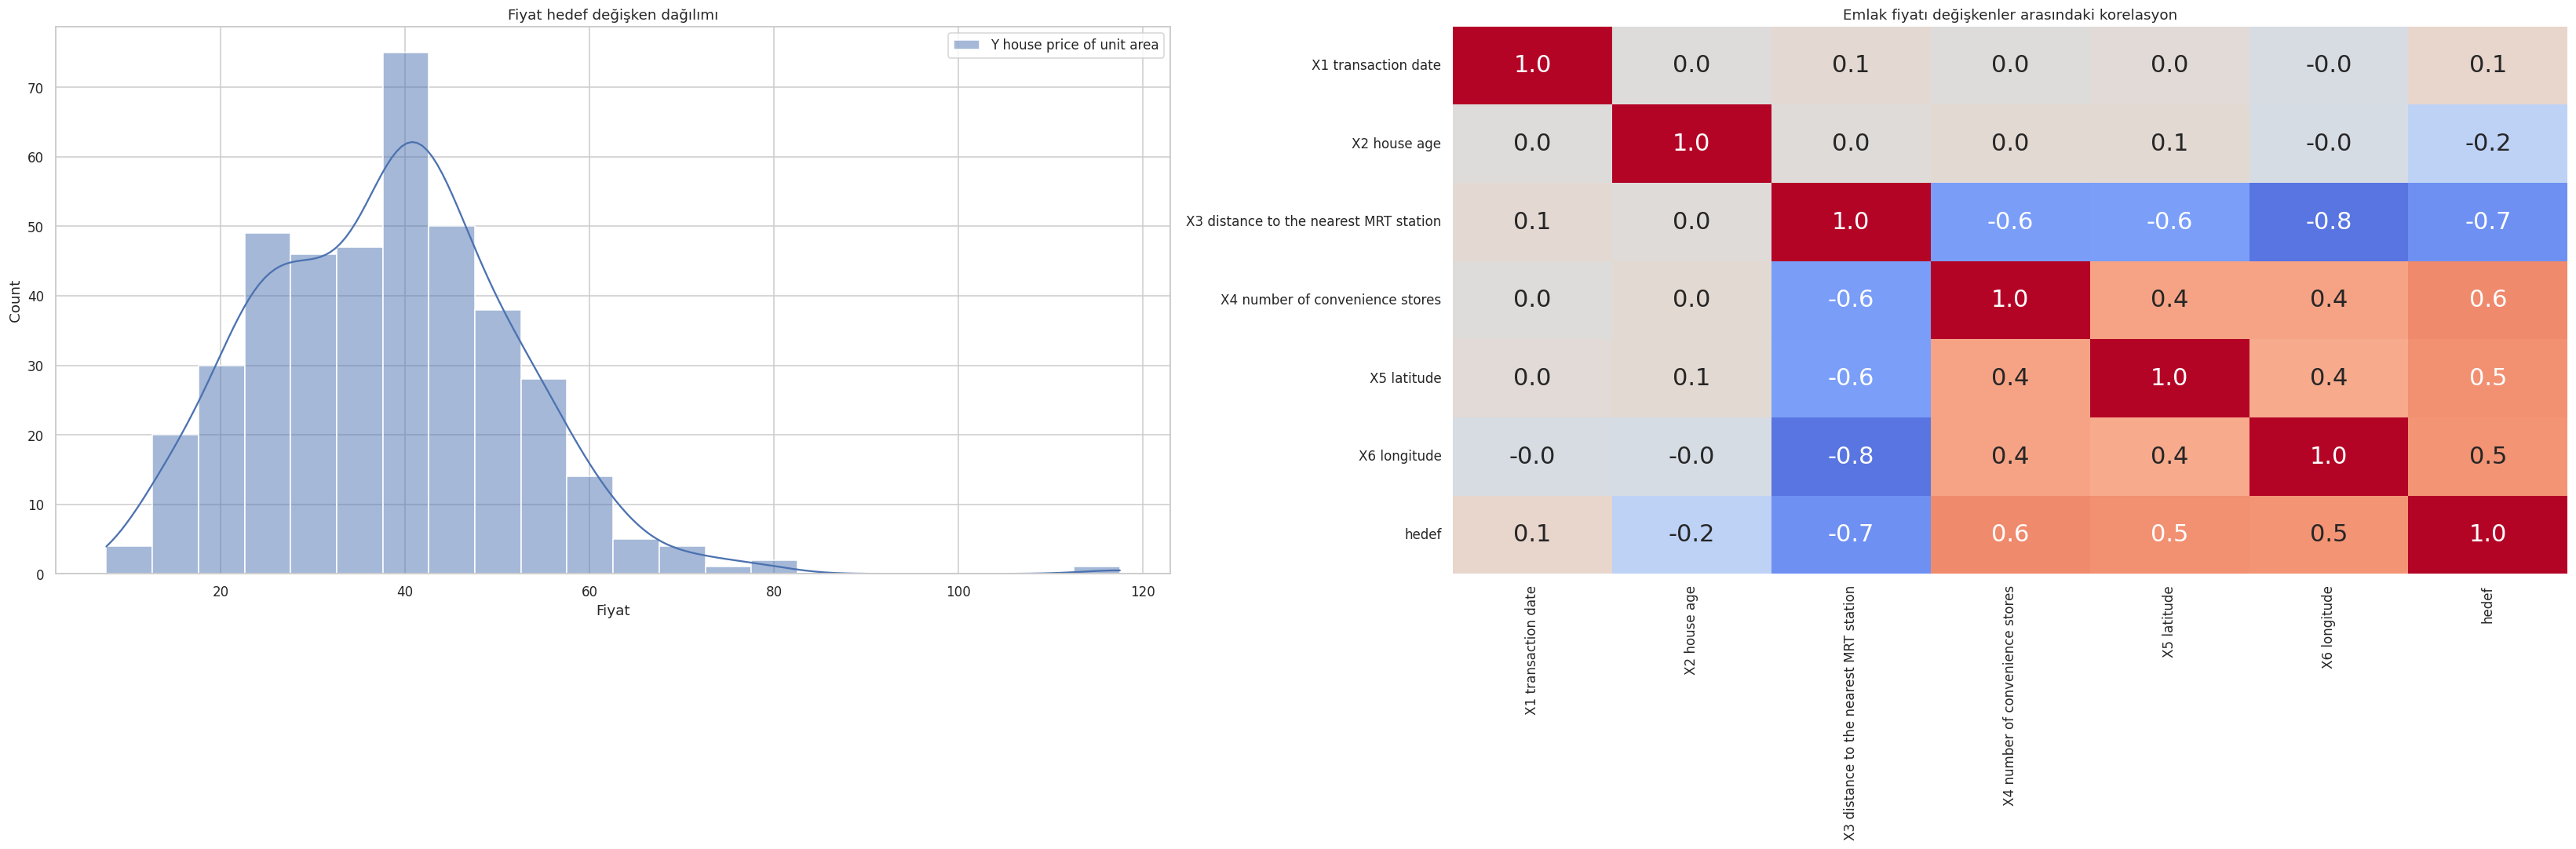

In [31]:
fig, axes = plt.subplots(1,2, figsize=(30,10))

sns.histplot(y,kde=True,ax=axes[0],color="steelblue")
axes[0].set_title("Fiyat hedef değişken dağılımı")
axes[0].set_xlabel("Fiyat")

corr =pd.concat([X,y.rename(columns={y.columns[0]: 'hedef'})],axis =1).corr()
sns.heatmap(corr,annot=True,fmt=".1f",cmap="coolwarm",center=0,
            axes=axes[1],cbar=False, annot_kws ={"size":20})
axes[1].set_title("Emlak fiyatı değişkenler arasındaki korelasyon")

plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
Xr_train,Xr_test,yr_train,yr_test=train_test_split(X,y,test_size=0.2,random_state=SEED)

In [33]:
print(f"{Xr_train.shape[0]}")
Xr_test.shape[0]

331


83

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean").fit(Xr_train,yr_train)

linear = LinearRegression().fit(Xr_train,yr_train)

def regresyon_raporu (model,X, y,ad):
  tahmin=model.predict(X)
  return{
     "Model" :ad,
     "Mae"   : mean_absolute_error(y,tahmin),
     "mse"   : mean_squared_error(y,tahmin),
     "rmse"  : np.sqrt(mean_squared_error(y,tahmin)),
     "r2"    : r2_score(y,tahmin)
    }
sonuc = pd.DataFrame([
    regresyon_raporu(baseline,Xr_train,yr_train,"Baseline"),
    regresyon_raporu(linear,Xr_test,yr_test,"Linear")
]).set_index("Model").round(3)
sonuc


,Mae,mse,rmse,r2
Model,,,,
Baseline,10.649,188.091,13.715,0.000
Linear,5.305,53.506,7.315,0.681


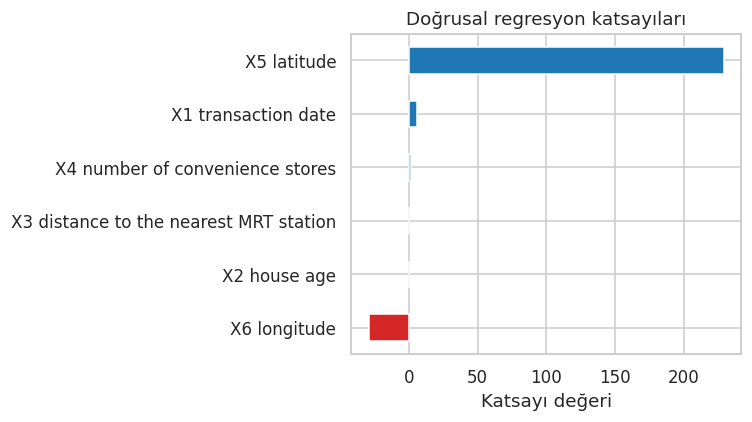

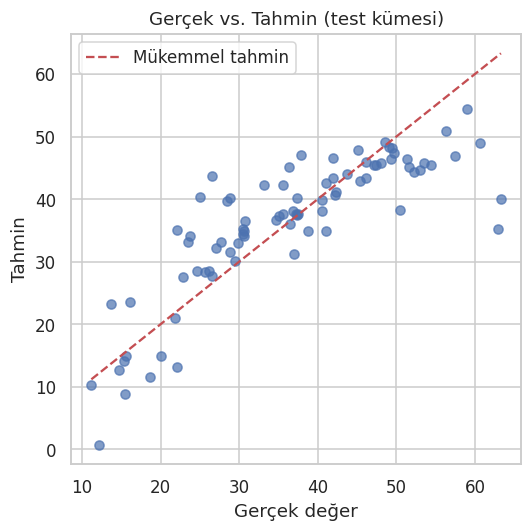

In [37]:
katsayilar = pd.Series(linear.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(7, 4))
katsayilar.plot(kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red"))
plt.title("Doğrusal regresyon katsayıları")
plt.xlabel("Katsayı değeri")
plt.tight_layout()
plt.show()

tahmin = linear.predict(Xr_test)
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, tahmin, alpha=0.7)
lim = [yr_test.min().item(), yr_test.max().item()] # Convert Series to scalar for plotting
plt.plot(lim, lim, "r--", label="Mükemmel tahmin")
plt.xlabel("Gerçek değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs. Tahmin (test kümesi)")
plt.legend()
plt.tight_layout()
plt.show()